In [1]:
# Import libraries
import numpy as np  
import matplotlib.pyplot as plt 
import cv2 as cv  

In [2]:
# Read an image from the given file path
def read_image(image_path):
    return cv.imread(image_path)

# Resize the image only if its largest dimension exceeds the given limit
def resize_if_needed(img, dim_limit=1000):
    max_dim = np.max(img.shape[:2])

    # Scale down the image while preserving aspect ratio
    if max_dim > dim_limit:
        resize_scale = dim_limit / max_dim
        img = cv.resize(img, None, fx=resize_scale, fy=resize_scale)

    return img

# Suppress small text regions using morphological closing
def suppress_text_with_morphology(img):
    kernel = np.ones((5, 5), np.uint8)
    close = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel, iterations=3)
    return close

# Detect edges using Canny, then strengthen and connect edge fragments
def compute_canny(img):
    edges = cv.Canny(img, 100, 200)

    # Close small gaps and slightly expand edges
    kernel = np.ones((5, 5), np.uint8)
    edges = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel, iterations=3)
    edges = cv.dilate(edges, kernel)

    return edges

# Extract contours from a binary edge image
def find_contours(edges):
    contours, _ = cv.findContours(edges, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    return contours

# Compute the angle formed by three points
def angle(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2

    # Compute cosine of the angle using the dot product formula
    cos_theta = np.dot(v1, v2) / (
        np.linalg.norm(v1) * np.linalg.norm(v2)
    )

    # Clamp value to avoid numerical instability
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    return np.degrees(np.arccos(cos_theta))

# Find the best page candidate as a large quadrilateral with near-right angles
def find_page_corners(contours, h, w):
    page_corners = None
    max_area = 0

    for contour in contours:
        area = cv.contourArea(contour)

        # Ignore contours that are too small relative to the image size
        if area < (w*h) / 10:
            continue

        # Use convex hull and polygon approximation to simplify the shape
        hull = cv.convexHull(contour)
        epsilon = 0.02 * cv.arcLength(hull, True)
        approx = cv.approxPolyDP(hull, epsilon, True)

        # Keep only 4-sided candidates
        if len(approx) == 4:
            pts = approx.reshape(4, 2)
            angles = []

            # Measure all internal angles of the quadrilateral
            for i in range(4):
                p1 = pts[(i - 1) % 4]
                p2 = pts[i]
                p3 = pts[(i + 1) % 4]
                angles.append(angle(p1, p2, p3))

            # Select the largest quadrilateral whose angles are close to 90 degrees
            if all(75 <= a <= 105 for a in angles) and area > max_area:
                max_area = area
                page_corners = approx

    return page_corners

# Close larger gaps between edge segments
def close_edge_gaps(edges):
    kernel = np.ones((25, 25), np.uint8)
    edges = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel, iterations=2)
    return edges

# Compute gradient magnitude using Sobel operators
def compute_sobel_gradient(img):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Compute horizontal and vertical gradients
    gradx = cv.Sobel(gray, cv.CV_32F, 1, 0, ksize=3)
    grady = cv.Sobel(gray, cv.CV_32F, 0, 1, ksize=3)

    # Combine gradients into a single magnitude image
    grad = cv.magnitude(gradx, grady)
    grad = cv.convertScaleAbs(grad)

    return grad

# Convert gradient image to binary using adaptive thresholding
def threshold_gradient_image(grad):
    binary = cv.adaptiveThreshold(
        grad,
        255,
        cv.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv.THRESH_BINARY,
        15,
        -10
    )

    return binary

# Remove contours whose area is smaller than the minimum threshold
def filter_small_contours(contours, min_area=50):
    valid_contours = []

    for cnt in contours:
        area = cv.contourArea(cnt)

        # Skip tiny contours that are likely noise
        if area < min_area:
            continue

        valid_contours.append(cnt)

    return valid_contours

# Extract four extreme corner points from all valid contour points
def extract_corner_points_from_contours(valid_contours):
    if not valid_contours:
        return None

    # Stack all contour points into a single point set
    all_points = np.vstack(valid_contours).reshape(-1, 2)

    # Use coordinate sum and difference to estimate page corners
    s = all_points.sum(axis=1)
    diff = np.diff(all_points, axis=1).reshape(-1)

    top_left = all_points[np.argmin(s)]
    bottom_right = all_points[np.argmax(s)]
    top_right = all_points[np.argmin(diff)]
    bottom_left = all_points[np.argmax(diff)]

    page_corners = np.array([
        top_left,
        top_right,
        bottom_right,
        bottom_left
    ], dtype=np.int32)

    return page_corners

# Return the contour with the largest area
def find_largest_contour(contours):
    if not contours:
        return None

    return max(contours, key=cv.contourArea)

# Convert the bounding rectangle of a contour into four corner points
def bounding_rect_to_contour(contour):
    if contour is None:
        return None

    x, y, w, h = cv.boundingRect(contour)

    page_corners = np.array([
        [x, y],
        [x + w, y],
        [x + w, y + h],
        [x, y + h]
    ], dtype=np.int32)

    return page_corners

# Score page corners based on area and rectangularity
def score_page_corners(page_corners):
    if page_corners is None:
        return 0

    pts = page_corners.reshape(-1, 2).astype(np.float32)

    # Compute detected page area
    area = cv.contourArea(pts)

    # Compute rectangularity using bounding box ratio
    x, y, w, h = cv.boundingRect(pts.astype(np.int32))
    rect_area = w * h

    if rect_area == 0:
        return 0

    rectangularity = area / rect_area

    # Favor large and well-rectangular page candidates
    score = area * (rectangularity ** 2)

    return score

# Select the better page candidate based on the scoring function
def select_better_page_corners(page_corners_1, page_corners_2):
    score_1 = score_page_corners(page_corners_1)
    score_2 = score_page_corners(page_corners_2)

    if score_1 >= score_2:
        return page_corners_1

    return page_corners_2

# Score a frame based on page size and rectangularity
def score_frame(page_corners, img):
    if page_corners is None:
        return 0.0

    pts = page_corners.reshape(-1, 2).astype(np.float32)

    area = cv.contourArea(pts)
    if area <= 0:
        return 0.0

    x, y, w, h = cv.boundingRect(pts.astype(np.int32))
    rect_area = w * h
    if rect_area <= 0:
        return 0.0

    # Measure how close the detected region is to a rectangle
    rectangularity = area / rect_area

    # Normalize page area with respect to the image size
    h_img, w_img = img.shape[:2]
    image_area = h_img * w_img
    normalized_area = area / image_area

    # Combine area and shape quality into a final frame score
    score = 0.2 * normalized_area + 0.8 * rectangularity
    return float(score)

# Draw the detected page boundary on the image
def draw_detected_page(img, page_corners):
    img_result = img.copy()

    if page_corners is not None:
        pts = page_corners.reshape((-1, 1, 2))
        cv.polylines(img_result, [pts], True, (0, 0, 255), 3)

    return img_result

# Order page corner points consistently as top-left, top-right, bottom-right, bottom-left
def order_page_points(page_corners):
    if page_corners is not None:
        p = page_corners.reshape(4, 2)
    else:
        return None

    s = p.sum(axis=1)
    diff = np.diff(p, axis=1)

    tl = p[np.argmin(s)]
    br = p[np.argmax(s)]
    tr = p[np.argmin(diff)]
    bl = p[np.argmax(diff)]

    return tl, tr, br, bl

# Apply perspective transform to obtain a top-down view of the page
def perspective_transform(img, page_corners):
    ordered_points = order_page_points(page_corners)

    if ordered_points is None:
        return None

    tl, tr, br, bl = ordered_points

    src = np.float32([tl, tr, br, bl])

    # Estimate output width and height from page edges
    width = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))
    height = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))

    # Define target rectangle corners
    dst = np.float32([
        [0, 0],                  # Top-left
        [width - 1, 0],          # Top-right
        [width - 1, height - 1], # Bottom-right
        [0, height - 1]          # Bottom-left
    ])

    # Compute perspective transform matrix and warp the image
    matrix = cv.getPerspectiveTransform(src, dst)
    warped = cv.warpPerspective(img, matrix, (width, height))

    return warped

# Remove uneven illumination and shadows from the warped page
def remove_shadows(warped):
    if warped is None:
        return None
    
    # Convert warped page to grayscale
    img = cv.cvtColor(warped, cv.COLOR_BGR2GRAY)

    # Estimate smooth background using morphological closing
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (21, 21))
    background = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel)

    # Normalize image intensity by dividing by the estimated background
    result = cv.divide(img, background, scale=255)

    # Binarize the normalized page for a clean document-like output
    result = cv.adaptiveThreshold(
        result,                          # Input image
        255,                             # Max output value
        cv.ADAPTIVE_THRESH_GAUSSIAN_C,   # Gaussian local threshold
        cv.THRESH_BINARY,                # Binary output
        15,                              # Block size
        10                               # Constant subtraction
    )

    return result

# Display all main processing stages for visual inspection
def show_results(img_original, edges, img_result, warped, result):
    plt.figure(figsize=(12, 8))

    plt.subplot(231); plt.imshow(img_original[..., ::-1]); plt.title("Original Best Frame")
    plt.subplot(232); plt.imshow(edges, cmap="gray"); plt.title("Edges of Best Frame")
    plt.subplot(233); plt.imshow(img_result[..., ::-1]); plt.title("Detected Page in Best Frame")
    plt.subplot(234); plt.imshow(warped[..., ::-1]); plt.title("Perspective Transform of Best Frame")
    plt.subplot(235); plt.imshow(result, cmap='gray'); plt.title("Final Result from Best Frame")
    plt.tight_layout()
    plt.show()

# Detect whether document and background have similar brightness appearance
def detect_similarity(img, diff_threshold=50):
    # Convert image to LAB color space
    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

    # Extract L channel
    L = lab[:, :, 0]

    # Smooth L channel
    L_blur = cv.GaussianBlur(L, (5, 5), 0)

    # Segment foreground/background using Otsu
    _, mask = cv.threshold(L_blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    # Invert mask if foreground is too large
    if np.sum(mask == 255) > np.sum(mask == 0):
        mask = cv.bitwise_not(mask)

    # Collect foreground pixels
    fg = L[mask == 255]

    # Collect background pixels
    bg = L[mask == 0]

    # Return unknown if segmentation fails
    if len(fg) == 0 or len(bg) == 0:
        return {"label": "unknown", "score": None}

    # Compute foreground mean intensity
    fg_mean = np.mean(fg)

    # Compute background mean intensity
    bg_mean = np.mean(bg)

    # Compute intensity difference score
    score = abs(fg_mean - bg_mean)

    # Decide similarity label
    label = True if score < diff_threshold else False

    # Return similarity result
    return label


In [3]:
# Detect the document page from a video and select the best frame
def detect_page(video_path):
    cap = cv.VideoCapture(video_path)

    # Keep track of the best detected page across all frames
    best_score = -1
    best_frame = None
    best_page_corners = None
    best_edges = None
    
    while True:
        # Read the next frame from the video
        ret, frame_original = cap.read()

        if not ret:
            break

        # Resize frame if needed for faster and more stable processing
        frame = resize_if_needed(frame_original)

        edges = None
        page_corners = None

        # Check whether page and background are visually similar
        label = detect_similarity(frame)

        # Case 1: Page and background are different enough
        if not label:
            # Suppress internal text content to emphasize outer page structure
            remove_text = suppress_text_with_morphology(frame)
            edges = compute_canny(remove_text)
            contours = find_contours(edges)
            h, w = edges.shape[:2]
            page_corners = find_page_corners(contours, h, w)

            # If page is not found, try closing larger edge gaps and search again
            if page_corners is None:
                edges = close_edge_gaps(edges)
                contours = find_contours(edges)
                page_corners = find_page_corners(contours, h, w)

        # Case 2: Page and background are visually similar
        else:
            # Strategy A: Detect page from content distribution using gradient information
            grad = compute_sobel_gradient(frame)
            binary = threshold_gradient_image(grad)
            contours_1 = find_contours(binary)
            valid_contours = filter_small_contours(contours_1)
            page_corners_1 = extract_corner_points_from_contours(valid_contours)

            # Strategy B: Detect page using outer edge grouping and bounding rectangle
            edges = compute_canny(frame)
            edges = close_edge_gaps(edges)
            contours_2 = find_contours(edges)
            largest_contour = find_largest_contour(contours_2)
            page_corners_2 = bounding_rect_to_contour(largest_contour)

            # Select the better result between the two strategies
            page_corners = select_better_page_corners(page_corners_1, page_corners_2)

            # If the content-based method wins, show its binary map as the edge result
            if np.array_equal(page_corners, page_corners_1):
                edges = binary
            
        # Score current frame and keep the best one
        score = score_frame(page_corners, frame)
        if score > best_score:
            best_score = score
            best_frame = frame
            best_edges = edges
            best_page_corners = page_corners
    
    # Draw, rectify, enhance, and display the final best result
    img_result = draw_detected_page(best_frame, best_page_corners)
    warped = perspective_transform(best_frame, best_page_corners)
    result = remove_shadows(warped)
    show_results(best_frame, best_edges, img_result, warped, result)

    cap.release()
    cv.destroyAllWindows()



Processing: videos/input_1.mp4


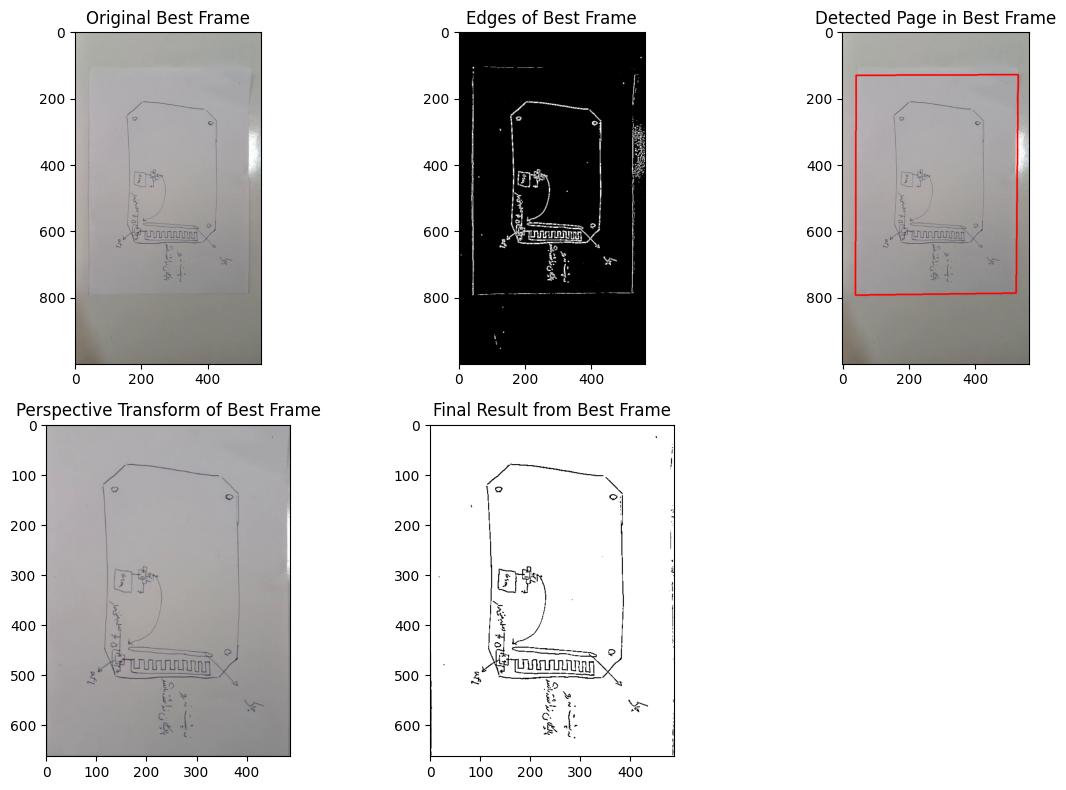


Processing: videos/input_2.mp4


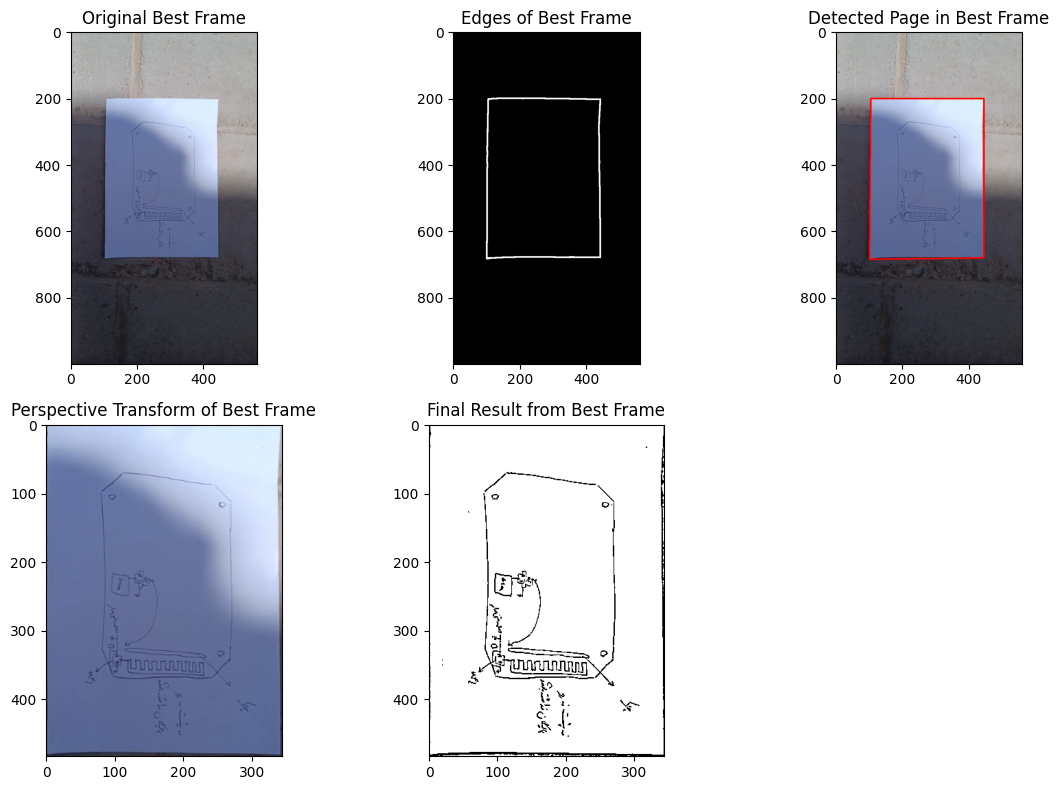


Processing: videos/input_3.mp4


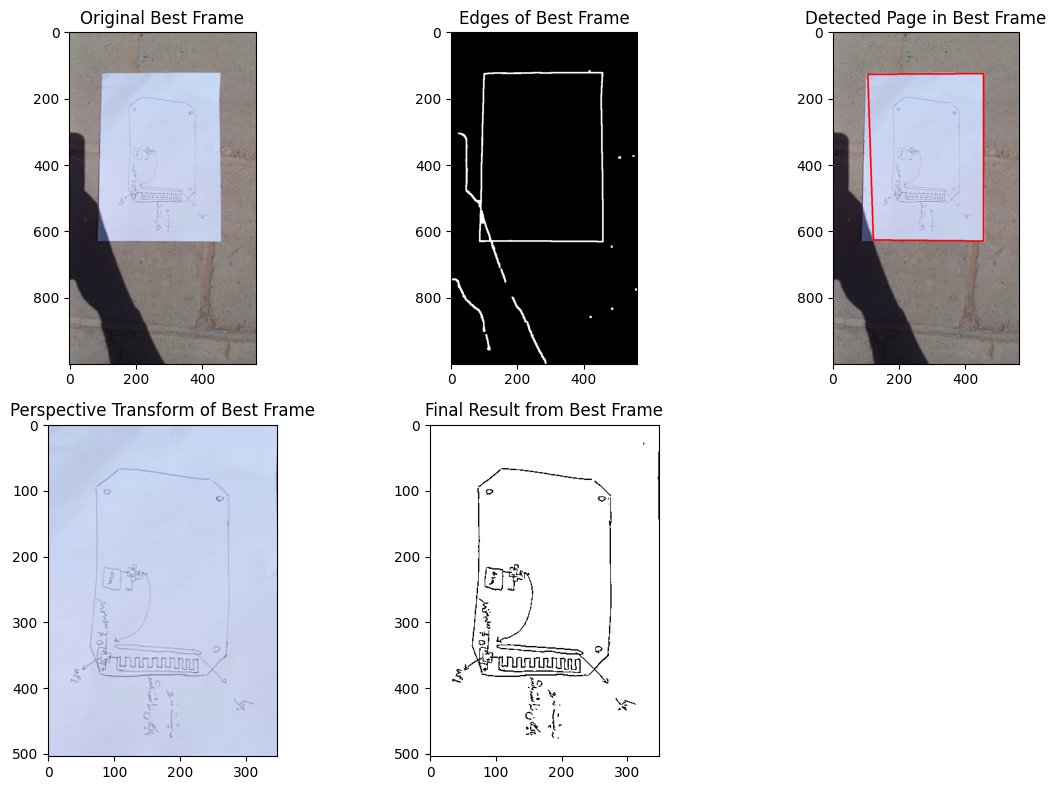


Processing: videos/input_4.mp4


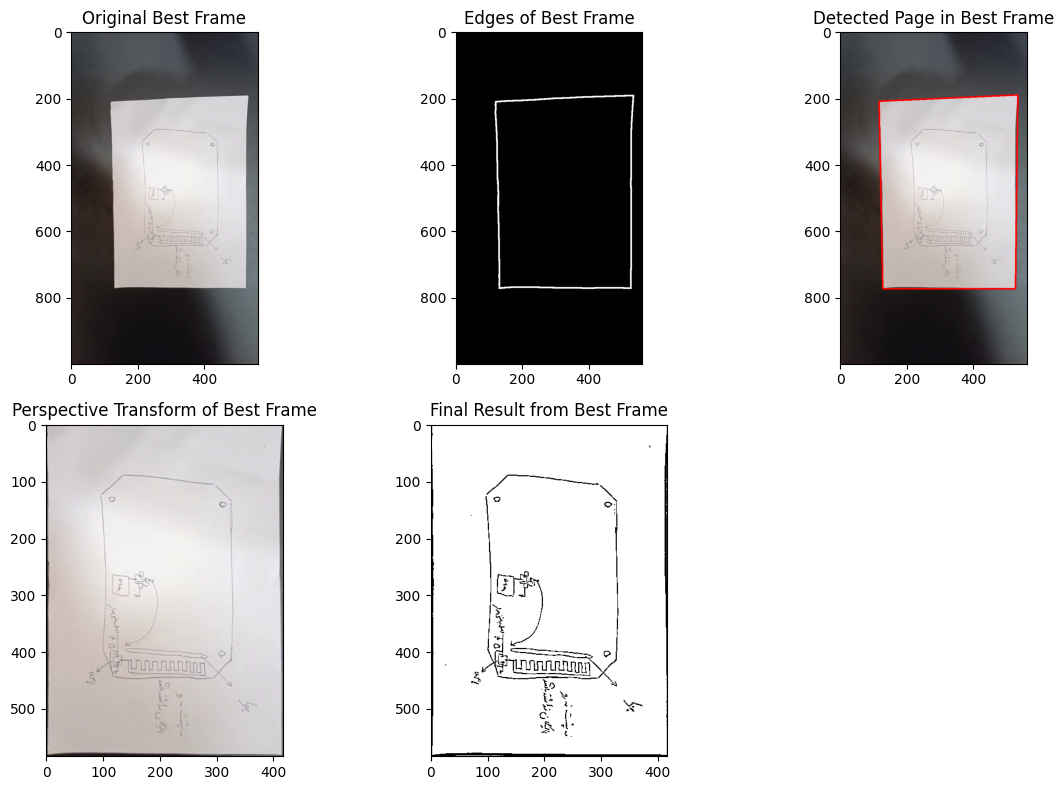


Processing: videos/input_5.mp4


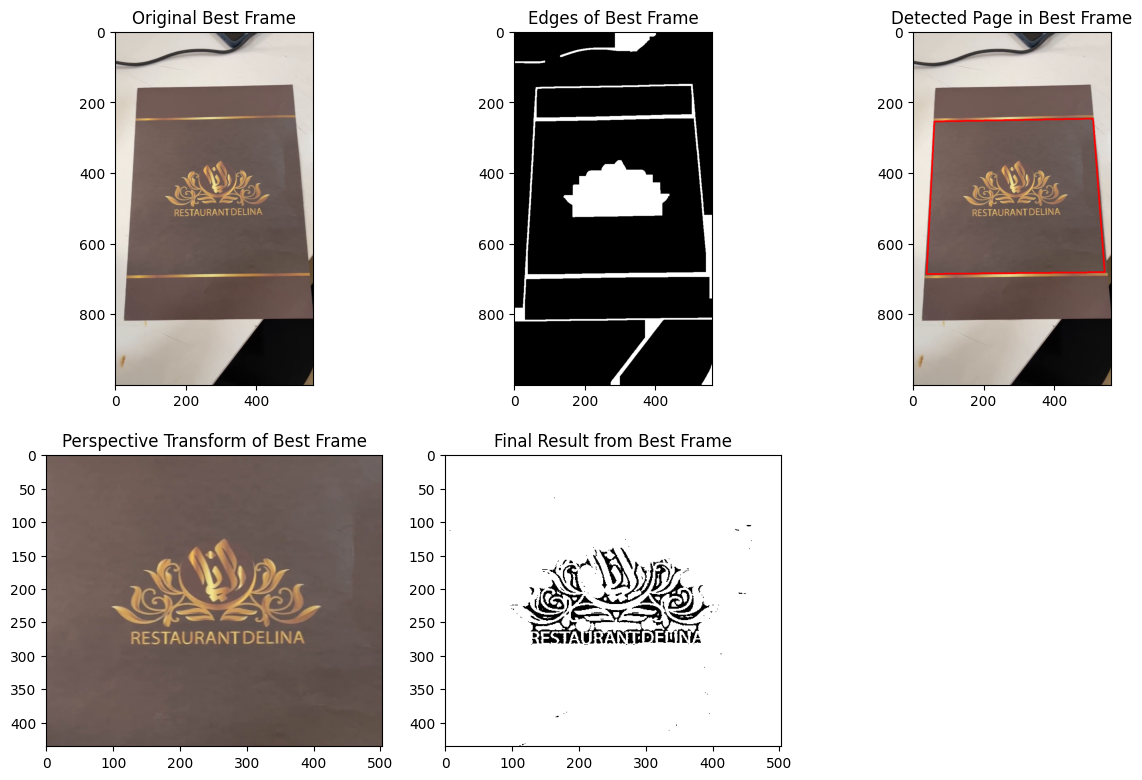

In [4]:
# List of input video files to process
videos = [
    "videos/input_1.mp4",   # First video
    "videos/input_2.mp4",   # Second video
    "videos/input_3.mp4",   # Third video
    "videos/input_4.mp4",   # Fourth video
    "videos/input_5.mp4",   # Fifth video
]

# Process all videos sequentially
for video_path in videos:
    # Show which video is currently being processed
    print(f"\nProcessing: {video_path}")

    # Run the full document detection pipeline on the current video
    detect_page(video_path)
